## Auto-Encoders
Instead of labels, we will use training images as both network input and output. The main idea of **autoencoder** is that we will have an **encoder network** that converts input image into some **latent space** (normally it is just a vector of some smaller size), then the **decoder network**, whose goal would be to reconstruct the original image.

In [3]:
import tensorflow as tf
from tensorflow.keras.datasets import mnist
import numpy as np
import matplotlib.pyplot as plt

In [7]:
with np.load('../../data/mnist.npz', allow_pickle=False) as f:
    x_train, y_train = f['x_train'], f['y_train']
    x_test, y_test = f['x_test'], f['y_test']

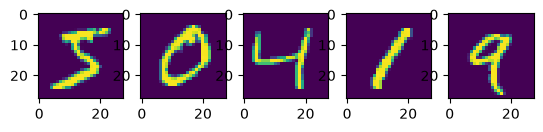

In [ ]:
def plotn(n,x):
    fig,ax = plt.subplots(1,n)
    for i,z in enumerate(x[0:n]):
        ax[i].imshow(z.reshape(28,28) if z.size==28*28 else z.reshape(14,14) if z.size==14*14 else z)
    plt.show()
  
plotn(5,x_train)

In [ ]:
from tensorflow.keras.layers import Input, Dense, Conv2D, MaxPooling2D, UpSampling2D, Lambda
from tensorflow.keras.models import Model
from tensorflow.keras.losses import binary_crossentropy, mse

input_img = Input(shape = (28, 28, 1))

"""
The default padding of keras is 'valid'. Example:
- If you pass a 28x28 image through a 3x3 filter without padding, the output becomes 26x26.
- Pass it through another one, and it becomes 24x24.

When set the padding = 'same', Keras automatically adds a border of artificial pixels (usually zeros) around the outside edges of your image before applying the filter. This is also called zero-padding.
"""

x = Conv2D(16, (3, 3), activation='relu', padding='same')(input_img)
x = MaxPooling2D((2, 2), padding = 'same')(x)
x = Conv2D(8, (3, 3), activation = 'relu', padding = 'same')(x)
x = MaxPooling2D((2, 2), padding = 'same')(x)
x = Conv2D(8, (3, 3), activation = 'relu', padding = 'same')(x)
encoded = MaxPooling2D((2, 2), padding = 'same')(x)

encoder = Model(input_img, encoded)

input_rep = Input(shape = (4, 4, 8))

x = Conv2D(8, (3, 3), activation = 'relu', padding = 'same')(input_rep)
x = UpSampling2D((2, 2))(x)
x = Conv2D(8, (3, 3), activation = 'relu', padding = 'same')(x)
x = UpSampling2D((2, 2))(x)
x = Conv2D(16, (3, 3), activation = 'relu')(x)
x = UpSampling2D((2, 2))(x)
decoded = Conv2D(1, (3, 3), activation = 'sigmoid', padding = 'same')(x)

decoder = Model(input_rep, decoded)

autoencoder = Model(input_img, decoder(encoder(input_img)))
autoencoder.compile(optimizer = 'adam', loss = 'binary_crossentropy')

In [10]:
x_train = x_train.astype('float32') / 255.0
x_test = x_test.astype('float32') / 255.0

x_train = np.reshape(x_train, (len(x_train), 28, 28, 1))
x_test = np.reshape(x_test, (len(x_test), 28, 28, 1))

In [11]:
autoencoder.fit(
    x_train, x_train, 
    epochs = 25, 
    batch_size = 128, 
    shuffle = True,
    validation_data = (x_test, x_test)
)

Epoch 1/25
469/469 ━━━━━━━━━━━━━━━━━━━━ 10s 16ms/step - loss: 0.2095 - val_loss: 0.1470
Epoch 2/25
469/469 ━━━━━━━━━━━━━━━━━━━━ 9s 19ms/step - loss: 0.1366 - val_loss: 0.1275
Epoch 3/25
469/469 ━━━━━━━━━━━━━━━━━━━━ 7s 14ms/step - loss: 0.1240 - val_loss: 0.1189
Epoch 4/25
469/469 ━━━━━━━━━━━━━━━━━━━━ 7s 15ms/step - loss: 0.1172 - val_loss: 0.1133
Epoch 5/25
469/469 ━━━━━━━━━━━━━━━━━━━━ 6s 14ms/step - loss: 0.1127 - val_loss: 0.1097
Epoch 6/25
469/469 ━━━━━━━━━━━━━━━━━━━━ 6s 13ms/step - loss: 0.1095 - val_loss: 0.1073
Epoch 7/25
469/469 ━━━━━━━━━━━━━━━━━━━━ 7s 14ms/step - loss: 0.1070 - val_loss: 0.1050
Epoch 8/25
469/469 ━━━━━━━━━━━━━━━━━━━━ 7s 14ms/step - loss: 0.1051 - val_loss: 0.1030
Epoch 9/25
469/469 ━━━━━━━━━━━━━━━━━━━━ 7s 14ms/step - loss: 0.1035 - val_loss: 0.1019
Epoch 10/25
469/469 ━━━━━━━━━━━━━━━━━━━━ 7s 14ms/step - loss: 0.1022 - val_loss: 0.1005
Epoch 11/25
469/469 ━━━━━━━━━━━━━━━━━━━━ 6s 13ms/step - loss: 0.1010 - val_loss: 0.0997
Epoch 12/25
469/469 ━━━━━━━━━━━━━━━━━━━━

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 202ms/step


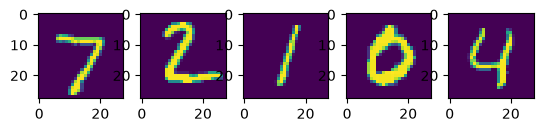

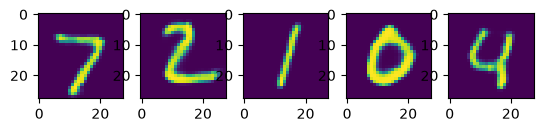

In [12]:
y_test = autoencoder.predict(x_test[0:5])
plotn(5, x_test)
plotn(5, y_test)

### Denoising
Autoencoders can be effectively used to **remove noise from images**. In order to train denoiser, we will start with **noise-free images**, and add **artificial noise** to them. Then, we will feed autoencoder with noisy images as input, and noise-free images as output.

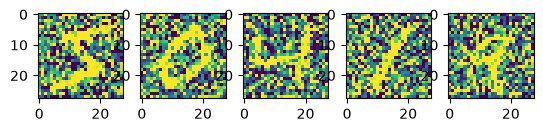

In [13]:
def noisify(data):
    return np.clip(data + np.random.normal(loc = 0.5, scale = 0.5, size = data.shape), 0.0, 1.0)

x_train_noise = noisify(x_train)
x_test_noise = noisify(x_test)

plotn(5, x_train_noise)

In [14]:
autoencoder.fit(
    x_train_noise, x_train,
    epochs = 25,
    batch_size = 128, 
    shuffle = True,
    validation_data = (x_test_noise, x_test)
)

Epoch 1/25
469/469 ━━━━━━━━━━━━━━━━━━━━ 8s 18ms/step - loss: 0.2729 - val_loss: 0.2402
Epoch 2/25
469/469 ━━━━━━━━━━━━━━━━━━━━ 9s 19ms/step - loss: 0.2283 - val_loss: 0.2176
Epoch 3/25
469/469 ━━━━━━━━━━━━━━━━━━━━ 7s 16ms/step - loss: 0.2115 - val_loss: 0.2051
Epoch 4/25
469/469 ━━━━━━━━━━━━━━━━━━━━ 8s 17ms/step - loss: 0.2012 - val_loss: 0.1972
Epoch 5/25
469/469 ━━━━━━━━━━━━━━━━━━━━ 7s 16ms/step - loss: 0.1942 - val_loss: 0.1902
Epoch 6/25
469/469 ━━━━━━━━━━━━━━━━━━━━ 8s 17ms/step - loss: 0.1886 - val_loss: 0.1842
Epoch 7/25
469/469 ━━━━━━━━━━━━━━━━━━━━ 7s 15ms/step - loss: 0.1834 - val_loss: 0.1790
Epoch 8/25
469/469 ━━━━━━━━━━━━━━━━━━━━ 7s 15ms/step - loss: 0.1790 - val_loss: 0.1763
Epoch 9/25
469/469 ━━━━━━━━━━━━━━━━━━━━ 7s 15ms/step - loss: 0.1751 - val_loss: 0.1734
Epoch 10/25
469/469 ━━━━━━━━━━━━━━━━━━━━ 7s 14ms/step - loss: 0.1716 - val_loss: 0.1684
Epoch 11/25
469/469 ━━━━━━━━━━━━━━━━━━━━ 7s 15ms/step - loss: 0.1685 - val_loss: 0.1683
Epoch 12/25
469/469 ━━━━━━━━━━━━━━━━━━━━ 

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step


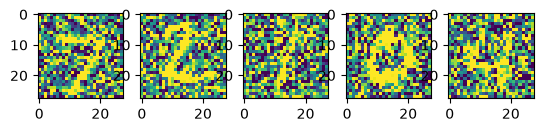

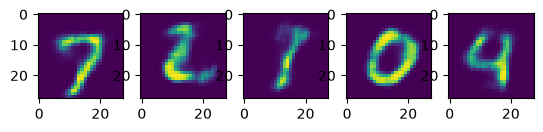

In [16]:
y_test_noise = autoencoder.predict(x_test_noise[0:5])
plotn(5, x_test_noise)
plotn(5, y_test_noise)

### Super-resolution
To train super-resolution network, we will start with **high-resolution images**, and automatically **downscale** them to produce network inputs. We will then feed autoencoder with small images as inputs and high-res images as outputs.

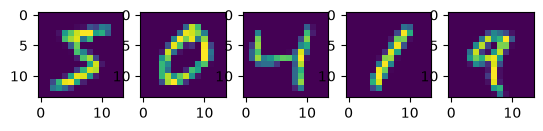

In [18]:
# Let's downscale MNIST to 14x14:
x_train_lr = tf.keras.layers.AveragePooling2D((2, 2))(x_train).numpy()
x_test_lr = tf.keras.layers.AveragePooling2D((2, 2))(x_test).numpy()

plotn(5, x_train_lr)

In [ ]:
input_img = Input(shape = (14, 14, 1))

x = Conv2D(16, (3, 3), activation = 'relu', padding = 'same')(input_img)